# EDA: сделки с квартирами в Москве 2011–2015

Данные соревнования Sberbank Russian Housing Market: ~30 тыс. сделок, 290 признаков (квартира + район + инфраструктура вокруг).

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src.config import RAW_DIR
plt.rcParams['figure.figsize'] = (10, 4)
raw = pd.read_csv(RAW_DIR / 'train.csv', parse_dates=['timestamp'])
raw.shape

(30471, 292)

In [2]:
raw[['full_sq', 'life_sq', 'kitch_sq', 'floor', 'max_floor', 'build_year', 'num_room', 'price_doc']].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
full_sq,30471.0,54.2,38.0,0.0,38.0,49.0,63.0,5326.0
life_sq,24088.0,34.4,52.3,0.0,20.0,30.0,43.0,7478.0
kitch_sq,20899.0,6.4,28.3,0.0,1.0,6.0,9.0,2014.0
floor,30304.0,7.7,5.3,0.0,3.0,6.5,11.0,77.0
max_floor,20899.0,12.6,6.8,0.0,9.0,12.0,17.0,117.0
build_year,16866.0,3068.1,154387.8,0.0,1967.0,1979.0,2005.0,20052009.0
num_room,20899.0,1.9,0.9,0.0,1.0,2.0,2.0,19.0
price_doc,30471.0,7123035.3,4780111.3,100000.0,4740002.0,6274411.0,8300000.0,111111112.0


Сразу видно мусор: площадь 5326 м², кухня 2014 м², год постройки 20052009, этажность 117.

## Распределение цен и «круглые» цены

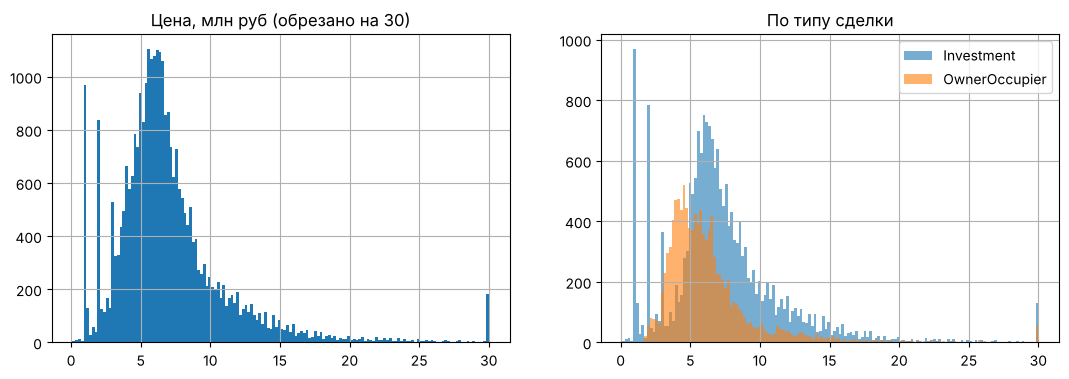

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
raw.price_doc.div(1e6).clip(upper=30).hist(bins=150, ax=ax[0])
ax[0].set_title('Цена, млн руб (обрезано на 30)')
for t, g in raw.groupby('product_type'):
    g.price_doc.div(1e6).clip(upper=30).hist(bins=150, ax=ax[1], alpha=0.6, label=t)
ax[1].legend(); ax[1].set_title('По типу сделки'); plt.show()

In [4]:
for p in [1e6, 2e6, 3e6]:
    s = raw[raw.price_doc == p]
    print(f'{p/1e6:.0f} млн: {len(s)} сделок, из них Investment: {(s.product_type == "Investment").mean():.0%}, '
          f'медианная площадь {s.full_sq.median():.0f} м2')

1 млн: 747 сделок, из них Investment: 100%, медианная площадь 43 м2
2 млн: 757 сделок, из них Investment: 100%, медианная площадь 45 м2
3 млн: 332 сделок, из них Investment: 100%, медианная площадь 44 м2


Пики ровно на 1, 2 и 3 млн почти целиком у инвестиционных сделок (вторичка), причём площадь у таких квартир обычная (~40–50 м²). Квартира в Москве за 1 млн в 2014 — нереально. Это почти наверняка занижение суммы в договоре. Такие строки в обучении — шум, который тянет прогноз вниз.

## Странная точка в центре

kremlin_km
20.5495    976
0.0729     603
23.3737    582
Name: count, dtype: int64


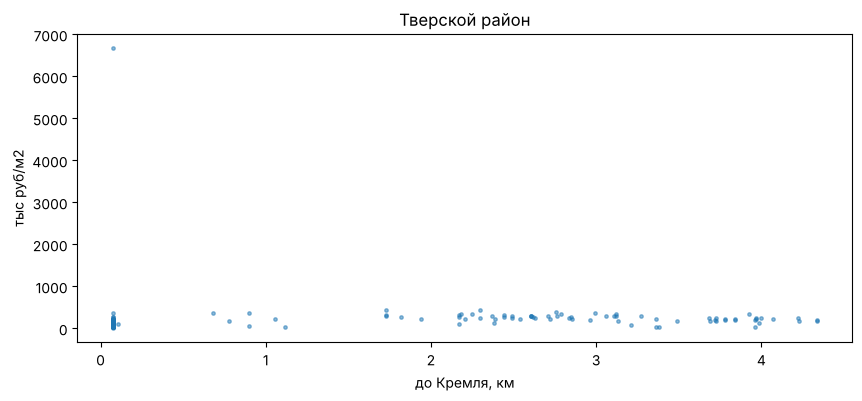

строк в точке 0.07 км: 603 из 678
доля новостроек среди них: 0.94
медиана цены м2: в точке 98709 | остальной Тверской 242105


In [5]:
print(raw.kremlin_km.round(4).value_counts().head(3))
t = raw[raw.sub_area == 'Tverskoe']
fig, ax = plt.subplots()
ax.scatter(t.kremlin_km, t.price_doc / t.full_sq / 1000, s=6, alpha=0.5)
ax.set_xlabel('до Кремля, км'); ax.set_ylabel('тыс руб/м2'); ax.set_title('Тверской район'); plt.show()
m = t.kremlin_km < 0.1
print('строк в точке 0.07 км:', m.sum(), 'из', len(t))
print('доля новостроек среди них:', round((t[m].product_type == 'OwnerOccupier').mean(), 2))
print('медиана цены м2: в точке', int((t[m].price_doc / t[m].full_sq).median()), '| остальной Тверской', int((t[~m].price_doc / t[~m].full_sq).median()))

600 сделок «в Кремле», почти все новостройки и в 2.5 раза дешевле, чем реальный Тверской район. Похоже, это квартиры с нераспознанным адресом, которые геокодер поставил в центр Москвы. Если оставить как есть, модель решит, что в Тверском районе квартиры дешёвые. В `src/clean.py` переношу их в район `Unknown` и обнуляю расстояния.

## Цена за м² и расстояние до центра

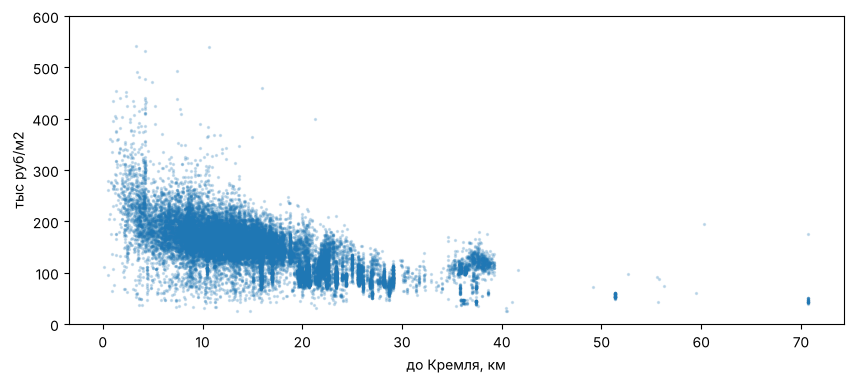

корреляция Спирмена: -0.701


In [6]:
d = raw[(raw.price_doc > 3e6) & (raw.full_sq.between(15, 200)) & (raw.kremlin_km > 0.1)]
ppsm = d.price_doc / d.full_sq / 1000
fig, ax = plt.subplots()
ax.scatter(d.kremlin_km, ppsm, s=2, alpha=0.2)
ax.set_ylim(0, 600); ax.set_xlabel('до Кремля, км'); ax.set_ylabel('тыс руб/м2'); plt.show()
print('корреляция Спирмена:', round(d.kremlin_km.corr(ppsm, method='spearman'), 3))

## Динамика цен: парадокс Симпсона

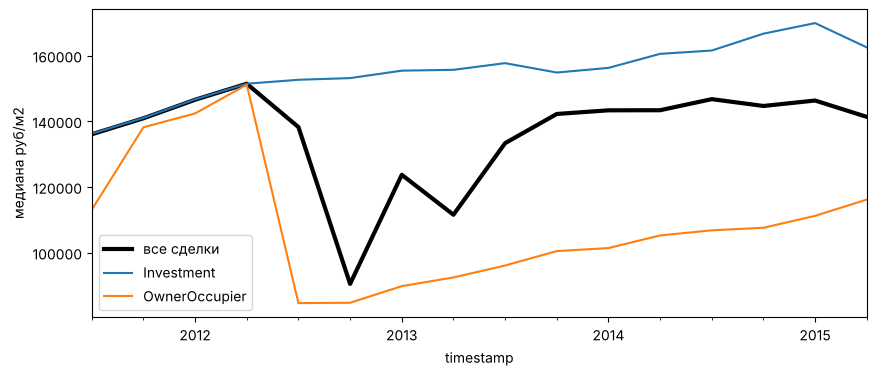

доля новостроек по годам: {2011: 0.01, 2012: 0.36, 2013: 0.44, 2014: 0.36, 2015: 0.48}


In [7]:
d = raw[~((raw.product_type == 'Investment') & raw.price_doc.isin([1e6, 2e6, 3e6]))]
d = d[d.full_sq.between(15, 300)]
q = d.timestamp.dt.to_period('Q')
ppsm = d.price_doc / d.full_sq
fig, ax = plt.subplots()
ppsm.groupby(q).median().plot(ax=ax, label='все сделки', lw=3, color='k')
for t in ['Investment', 'OwnerOccupier']:
    mask = d.product_type == t
    ppsm[mask].groupby(q[mask]).median().plot(ax=ax, label=t)
ax.legend(); ax.set_ylabel('медиана руб/м2'); plt.show()
print('доля новостроек по годам:', d.groupby(d.timestamp.dt.year).product_type.apply(lambda s: round((s == 'OwnerOccupier').mean(), 2)).to_dict())

Внутри каждого сегмента цена за метр стабильно растёт, а общая медиана скачет (в 4 кв. 2012 она проваливается до ~90 тыс., потому что 70% сделок квартала — новостройки): в 2011 новостроек в данных почти нет, а к 2015 это уже почти половина сделок, причём в основном дешёвые новостройки в Новой Москве. Для модели это важно: тренд надо считать по сегментам, иначе он будет отражать структуру сделок, а не рост цен.

## Пропуски

In [8]:
na = raw.isna().mean().sort_values(ascending=False)
print('признаков с пропусками > 30%:', (na > 0.3).sum())
na.head(12).round(2)

признаков с пропусками > 30%: 10


hospital_beds_raion           0.47
build_year                    0.45
state                         0.44
cafe_sum_500_min_price_avg    0.44
cafe_sum_500_max_price_avg    0.44
cafe_avg_price_500            0.44
kitch_sq                      0.31
material                      0.31
max_floor                     0.31
num_room                      0.31
preschool_quota               0.22
school_quota                  0.22
dtype: float64

In [9]:
# пропуски в параметрах квартиры не случайные: в начале периода многих полей просто нет
raw.groupby(raw.timestamp.dt.year)[['max_floor', 'material', 'num_room', 'kitch_sq', 'build_year']].apply(lambda g: g.isna().mean()).round(2)

,max_floor,material,num_room,kitch_sq,build_year
timestamp,,,,,
2011,1.0,1.0,1.0,1.0,1.00
2012,1.0,1.0,1.0,1.0,1.00
2013,0.5,0.5,0.5,0.5,0.60
2014,0.0,0.0,0.0,0.0,0.19
2015,0.0,0.0,0.0,0.0,0.21


До середины 2013 у сделок вообще нет `max_floor`, `material`, `num_room`, `kitch_sq`: видимо, источник данных поменялся. Импутировать их средним — значит выдумать данные, поэтому оставляю NaN, CatBoost умеет с ними работать.